# Signal Screening — All 7 Signals × 10 Sector ETFs

| Setting | Value |
|---|---|
| **IS** | 2010–2019 (optimisation only) |
| **OOS1** | 2020–2025 (forward validation) |
| **OOS2** | 2000–2009 (pre-sample stress-test) |
| **Lag** | 1-day (signal at close *t* → position from open *t+1*) |
| **Costs** | None (gross returns) |
| **Objective** | IS Sortino maximisation |

Signals: MA Crossover · RSI · Donchian · MACD · Bollinger · Stochastic · Z-Score

In [13]:
import importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pathlib
warnings.filterwarnings('ignore')
%matplotlib inline

import module
importlib.reload(module)

IS_START,   IS_END   = '2010-01-01', '2019-12-31'
OOS1_START, OOS1_END = '2020-01-01', '2025-12-31'
OOS2_START, OOS2_END = '2000-01-01', '2009-12-31'

SECTOR_ETFS = {
    'XLF':'Financials',   'XLK':'Technology',    'XLV':'Healthcare',
    'XLY':'Cons. Disc.',  'XLP':'Cons. Staples',  'XLE':'Energy',
    'XLI':'Industrials',  'XLB':'Materials',      'XLU':'Utilities',
    'IYR':'Real Estate',
}
print('Setup complete.')

Setup complete.


In [14]:
# sector_etfs_ext.csv covers 2000-2025 and includes IYR — use it for all periods
data_dir = pathlib.Path('data')

def load_csv(fname, tickers):
    df = pd.read_csv(data_dir / fname, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    return df[[t for t in tickers if t in df.columns]]

def cut(df, s, e):
    return df[(df.index >= s) & (df.index <= e)].copy()

TICKERS = list(SECTOR_ETFS.keys())

df_ext     = load_csv('sector_etfs_ext.csv', TICKERS)   # 2000-2025, has IYR
df_spx_ext = load_csv('spx_ext.csv',         ['^GSPC'])  # 2000-2025

df_is   = cut(df_ext, IS_START,   IS_END)
df_oos1 = cut(df_ext, OOS1_START, OOS1_END)
df_oos2 = cut(df_ext, OOS2_START, OOS2_END)

TICKERS = [t for t in TICKERS if t in df_is.columns]

def spx_sortino(s, e):
    px = cut(df_spx_ext, s, e).iloc[:, 0].to_numpy(dtype=float)
    dr = np.concatenate(([0.], px[1:] / px[:-1] - 1))
    return module.compute_sortino(dr[1:])

SPX_IS   = spx_sortino(IS_START,   IS_END)
SPX_OOS1 = spx_sortino(OOS1_START, OOS1_END)
SPX_OOS2 = spx_sortino(OOS2_START, OOS2_END)

print(f'ETFs loaded ({len(TICKERS)}): {TICKERS}')
print(f'S&P 500 Sortino  IS={SPX_IS:.3f}  OOS1={SPX_OOS1:.3f}  OOS2={SPX_OOS2:.3f}')

ETFs loaded (10): ['XLF', 'XLK', 'XLV', 'XLY', 'XLP', 'XLE', 'XLI', 'XLB', 'XLU', 'IYR']
S&P 500 Sortino  IS=1.099  OOS1=0.992  OOS2=-0.013


In [15]:
def backtest(signal_fn, series, params):
    ser = series.dropna()
    px  = ser.to_numpy(dtype=float)
    dr  = np.concatenate(([0.], px[1:] / px[:-1] - 1))
    sig = signal_fn(ser, **params)
    arr = sig['signal'].to_numpy(dtype=float)
    pos = np.concatenate(([0.], arr[:-1]))          # 1-day lag
    dn  = pos * dr
    return np.cumprod(1. + dn), dn


def optimise(signal_fn, series_is, grid):
    best_s, best_p = -np.inf, None
    for p in grid:
        try:
            _, dn = backtest(signal_fn, series_is, p)
            s = module.compute_sortino(dn[1:])
            if s == s and s > best_s:
                best_s, best_p = s, dict(p)
        except Exception:
            pass
    return best_p, float(best_s) if np.isfinite(best_s) else np.nan


def metrics(pv):
    dr = np.concatenate(([0.], pv[1:] / pv[:-1] - 1))
    return {
        'Sortino': module.compute_sortino(dr[1:]),
        'Sharpe':  module.compute_sharpe(dr[1:]),
        'CAGR':    module.compute_cagr(pv),
        'MaxDD':   module.compute_max_drawdown(pv),
    }

print('Backtest engine ready.')

Backtest engine ready.


In [16]:
SIGNAL_GRIDS = {
    'MA Cross': (
        module.ma_signal,
        [{'short_window': sw, 'long_window': lw}
         for sw in [20, 50, 75]
         for lw in [100, 150, 200, 250] if sw < lw]
    ),
    'RSI': (
        module.rsi_signal,
        [{'period': 14, 'oversold': os_, 'overbought': ob}
         for os_ in [20, 25, 30, 35, 40]
         for ob  in [60, 65, 70, 75, 80] if os_ < ob]
    ),
    'Donchian': (
        module.donchian_signal,
        [{'window': w} for w in [20, 40, 55, 75, 100, 150, 200]]
    ),
    'MACD': (
        module.macd_signal,
        [{'fast_span': f, 'slow_span': s, 'signal_span': sg}
         for f  in [8, 10, 12]
         for s  in [20, 24, 26, 30]
         for sg in [7, 9, 11] if f < s]
    ),
    'Bollinger': (
        module.bollinger_signal,
        [{'window': w, 'num_std': ns}
         for w  in [10, 20, 30, 50]
         for ns in [1.5, 2.0, 2.5]]
    ),
    'Stochastic': (
        module.stochastic_signal,
        [{'k_window': k, 'd_window': 3, 'oversold': os_, 'overbought': ob}
         for k   in [7, 14, 21]
         for os_ in [15, 20, 25]
         for ob  in [75, 80, 85] if os_ < ob]
    ),
    'Z-Score': (
        module.zscore_signal,
        [{'window': w, 'entry_threshold': et}
         for w  in [10, 20, 40, 60]
         for et in [1.5, 2.0, 2.5]]
    ),
}
sig_names = list(SIGNAL_GRIDS.keys())

total = sum(len(g) for _, g in SIGNAL_GRIDS.values()) * len(TICKERS)
print('Parameter grids:')
for sn, (_, g) in SIGNAL_GRIDS.items():
    print(f'  {sn:<12}: {len(g):>3} params x {len(TICKERS)} ETFs = {len(g)*len(TICKERS):>4} IS backtests')
print(f'  {"TOTAL":<12}: {total} IS backtests')

Parameter grids:
  MA Cross    :  12 params x 10 ETFs =  120 IS backtests
  RSI         :  25 params x 10 ETFs =  250 IS backtests
  Donchian    :   7 params x 10 ETFs =   70 IS backtests
  MACD        :  36 params x 10 ETFs =  360 IS backtests
  Bollinger   :  12 params x 10 ETFs =  120 IS backtests
  Stochastic  :  27 params x 10 ETFs =  270 IS backtests
  Z-Score     :  12 params x 10 ETFs =  120 IS backtests
  TOTAL       : 1310 IS backtests


In [17]:
print('Running IS optimisation (this takes ~2-3 min)...')
opt = {sn: {} for sn in sig_names}

for sig_name, (sig_fn, grid) in SIGNAL_GRIDS.items():
    print(f'  {sig_name}...', end=' ', flush=True)
    for tk in TICKERS:
        bp, bs = optimise(sig_fn, df_is[tk], grid)
        opt[sig_name][tk] = {'params': bp, 'is_sort': bs}
    print('done')

print('IS optimisation complete.')

Running IS optimisation (this takes ~2-3 min)...
  MA Cross... done
  RSI... done
  Donchian... done
  MACD... done
  Bollinger... done
  Stochastic... done
  Z-Score... done
IS optimisation complete.


In [18]:
def eval_period(df_period, sig_name, tk):
    bp = opt[sig_name][tk]['params']
    if bp is None or tk not in df_period.columns:
        return {k: np.nan for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    ser = df_period[tk].dropna()
    if len(ser) < 60:
        return {k: np.nan for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    try:
        pv, _ = backtest(SIGNAL_GRIDS[sig_name][0], ser, bp)
        return metrics(pv), pv
    except Exception:
        return {k: np.nan for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None

rows = []
pvs  = {}  # store equity curves for plotting
for sn in sig_names:
    for tk in TICKERS:
        is_s = opt[sn][tk]['is_sort']
        m1, pv1 = eval_period(df_oos1, sn, tk)
        m2, pv2 = eval_period(df_oos2, sn, tk)
        pvs[(sn, tk)] = (pv1, pv2)
        rows.append({
            'Signal':     sn,
            'ETF':        tk,
            'Sector':     SECTOR_ETFS[tk],
            'IS Sort':    round(is_s, 3),
            'OOS1 Sort':  round(m1['Sortino'], 3),
            'OOS2 Sort':  round(m2['Sortino'], 3),
            'OOS1 CAGR':  round(m1['CAGR'],    4),
            'OOS2 CAGR':  round(m2['CAGR'],    4),
            'OOS1 MaxDD': round(m1['MaxDD'],   4),
            'OOS2 MaxDD': round(m2['MaxDD'],   4),
            'OOS1 Sharpe':round(m1['Sharpe'],  3),
        })

df = pd.DataFrame(rows)
df['Min OOS']  = df[['OOS1 Sort', 'OOS2 Sort']].min(axis=1)
df['Avg OOS']  = df[['OOS1 Sort', 'OOS2 Sort']].mean(axis=1)
df['Beat OOS1']= df['OOS1 Sort'] > SPX_OOS1
df['Beat OOS2']= df['OOS2 Sort'] > SPX_OOS2
df['Beat Both']= df['Beat OOS1'] & df['Beat OOS2']
print(f'Results: {len(df)} combinations ({len(sig_names)} signals x {len(TICKERS)} ETFs)')

Results: 70 combinations (7 signals x 10 ETFs)


In [19]:
# All 70 combinations ranked by Min OOS Sortino
ranked = df.sort_values('Min OOS', ascending=False).reset_index(drop=True)
ranked.index += 1  # rank from 1

print(f'ALL {len(ranked)} SIGNAL x ETF COMBINATIONS — ranked by Min OOS Sortino')
print(f'S&P 500:  IS={SPX_IS:.3f}  |  OOS1={SPX_OOS1:.3f}  |  OOS2={SPX_OOS2:.3f}')
print(f'(* = beats S&P 500 in that period)')
print()

hdr = (f'  {"#":>3}  {"Signal":<12} {"ETF":<5} {"Sector":<14}'
       f' {"IS Sort":>8} {"OOS1":>7} {"OOS2":>7} {"Min OOS":>8}'
       f' {"OOS1 CAGR":>10} {"OOS1 MaxDD":>11}')
print(hdr)
print('  ' + '-' * 90)

for rank, r in ranked.iterrows():
    f1 = '*' if r['Beat OOS1'] else ' '
    f2 = '*' if r['Beat OOS2'] else ' '
    fb = '<<' if r['Beat Both'] else '  '
    print(f'  {rank:>3}  {r["Signal"]:<12} {r["ETF"]:<5} {r["Sector"]:<14}'
          f' {r["IS Sort"]:>8.3f}'
          f' {r["OOS1 Sort"]:>6.3f}{f1}'
          f' {r["OOS2 Sort"]:>6.3f}{f2}'
          f' {r["Min OOS"]:>8.3f}{fb}'
          f' {r["OOS1 CAGR"]:>10.2%}'
          f' {r["OOS1 MaxDD"]:>10.2%}')

print()
print(f'<< = beats S&P 500 in BOTH OOS periods')
n_both = int(df['Beat Both'].sum())
print(f'{n_both} / {len(df)} combinations beat S&P 500 in both OOS periods')

ALL 70 SIGNAL x ETF COMBINATIONS — ranked by Min OOS Sortino
S&P 500:  IS=1.099  |  OOS1=0.992  |  OOS2=-0.013
(* = beats S&P 500 in that period)

    #  Signal       ETF   Sector          IS Sort    OOS1    OOS2  Min OOS  OOS1 CAGR  OOS1 MaxDD
  ------------------------------------------------------------------------------------------
    1  Donchian     XLI   Industrials       0.916  1.017*  1.176*    1.017<<      8.91%    -19.12%
    2  Donchian     XLU   Utilities         1.033  0.681   1.075*    0.681        5.37%    -18.66%
    3  Donchian     XLK   Technology        1.185  1.096*  0.634*    0.634<<     13.16%    -20.38%
    4  MA Cross     XLE   Energy            0.471  0.614   0.826*    0.614        7.74%    -45.68%
    5  RSI          XLE   Energy            0.551  0.721   0.589*    0.589       10.82%    -58.14%
    6  RSI          XLB   Materials         1.030  0.857   0.529*    0.529       10.50%    -36.70%
    7  MACD         XLU   Utilities         0.631  1.125*  0.484*   

### Min OOS Sortino — Interpretation Scale

Min OOS = worst of OOS1 (2020–2025) and OOS2 (2000–2009). A strategy must hold up in **both** stress periods to score well.

S&P 500 Min OOS benchmark = min(0.992, −0.013) = **−0.013** — trivially easy to beat, so raw "beats benchmark" is not a meaningful bar here.

| Min OOS | # out of 63 | Quality verdict | Why |
|---|---|---|---|
| **< 0** | ~18/63 | ✗ Fail | Negative risk-adj returns in at least one OOS period |
| **0 – 0.3** | ~27/63 | ~ Marginal | Positive but weak; likely noise over a short OOS window |
| **0.3 – 0.5** | ~11/63 | ✓ Acceptable | Strategy survives both periods; borderline statistical significance |
| **0.5 – 0.8** | ~6/63 | ✓✓ Good | Solid OOS robustness; t-stat ≈ 1.6–2.5 over 10 yrs of OOS2 data |
| **> 0.8** | ~1/63 | ✓✓✓ Exceptional | Competitive with buy-and-hold on a risk-adj basis in both regimes |

**Why 0.5 is the practical cut-off:** OOS2 spans ~2500 trading days. A Sortino of 0.5 annualised implies a t-stat ≈ 1.6 — borderline significant. Below that, the result is statistically indistinguishable from luck. OOS2 (2000–2009, lost decade for equities) is typically the binding constraint — strategies that survive it with Min OOS > 0.5 have genuine cross-regime edge.

In [20]:
print('BEAT S&P 500 SUMMARY')
print(f'Benchmarks:  IS={SPX_IS:.3f}  OOS1={SPX_OOS1:.3f}  OOS2={SPX_OOS2:.3f}')
print()
hdr = f'  {"Signal":<12} {"Beat IS":>9} {"Beat OOS1":>11} {"Beat OOS2":>11} {"Beat Both":>11}'
print(hdr)
print('  ' + '-' * 50)
n = len(TICKERS)
for sn in sig_names:
    sub  = df[df['Signal'] == sn]
    bi   = int((sub['IS Sort']   > SPX_IS  ).sum())
    bo1  = int((sub['OOS1 Sort'] > SPX_OOS1).sum())
    bo2  = int((sub['OOS2 Sort'] > SPX_OOS2).sum())
    both = int(sub['Beat Both'].sum())
    print(f'  {sn:<12}  {bi:>3}/{n}       {bo1:>3}/{n}       {bo2:>3}/{n}       {both:>3}/{n}')
print('  ' + '-' * 50)
print(f'  (/{n} = out of {n} ETFs tested per signal)')

BEAT S&P 500 SUMMARY
Benchmarks:  IS=1.099  OOS1=0.992  OOS2=-0.013

  Signal         Beat IS   Beat OOS1   Beat OOS2   Beat Both
  --------------------------------------------------
  MA Cross        6/10         3/10         8/10         3/10
  RSI             7/10         1/10         8/10         0/10
  Donchian        4/10         2/10         9/10         2/10
  MACD            4/10         5/10         8/10         4/10
  Bollinger       8/10         0/10         9/10         0/10
  Stochastic      6/10         0/10         9/10         0/10
  Z-Score         8/10         1/10         9/10         1/10
  --------------------------------------------------
  (/10 = out of 10 ETFs tested per signal)


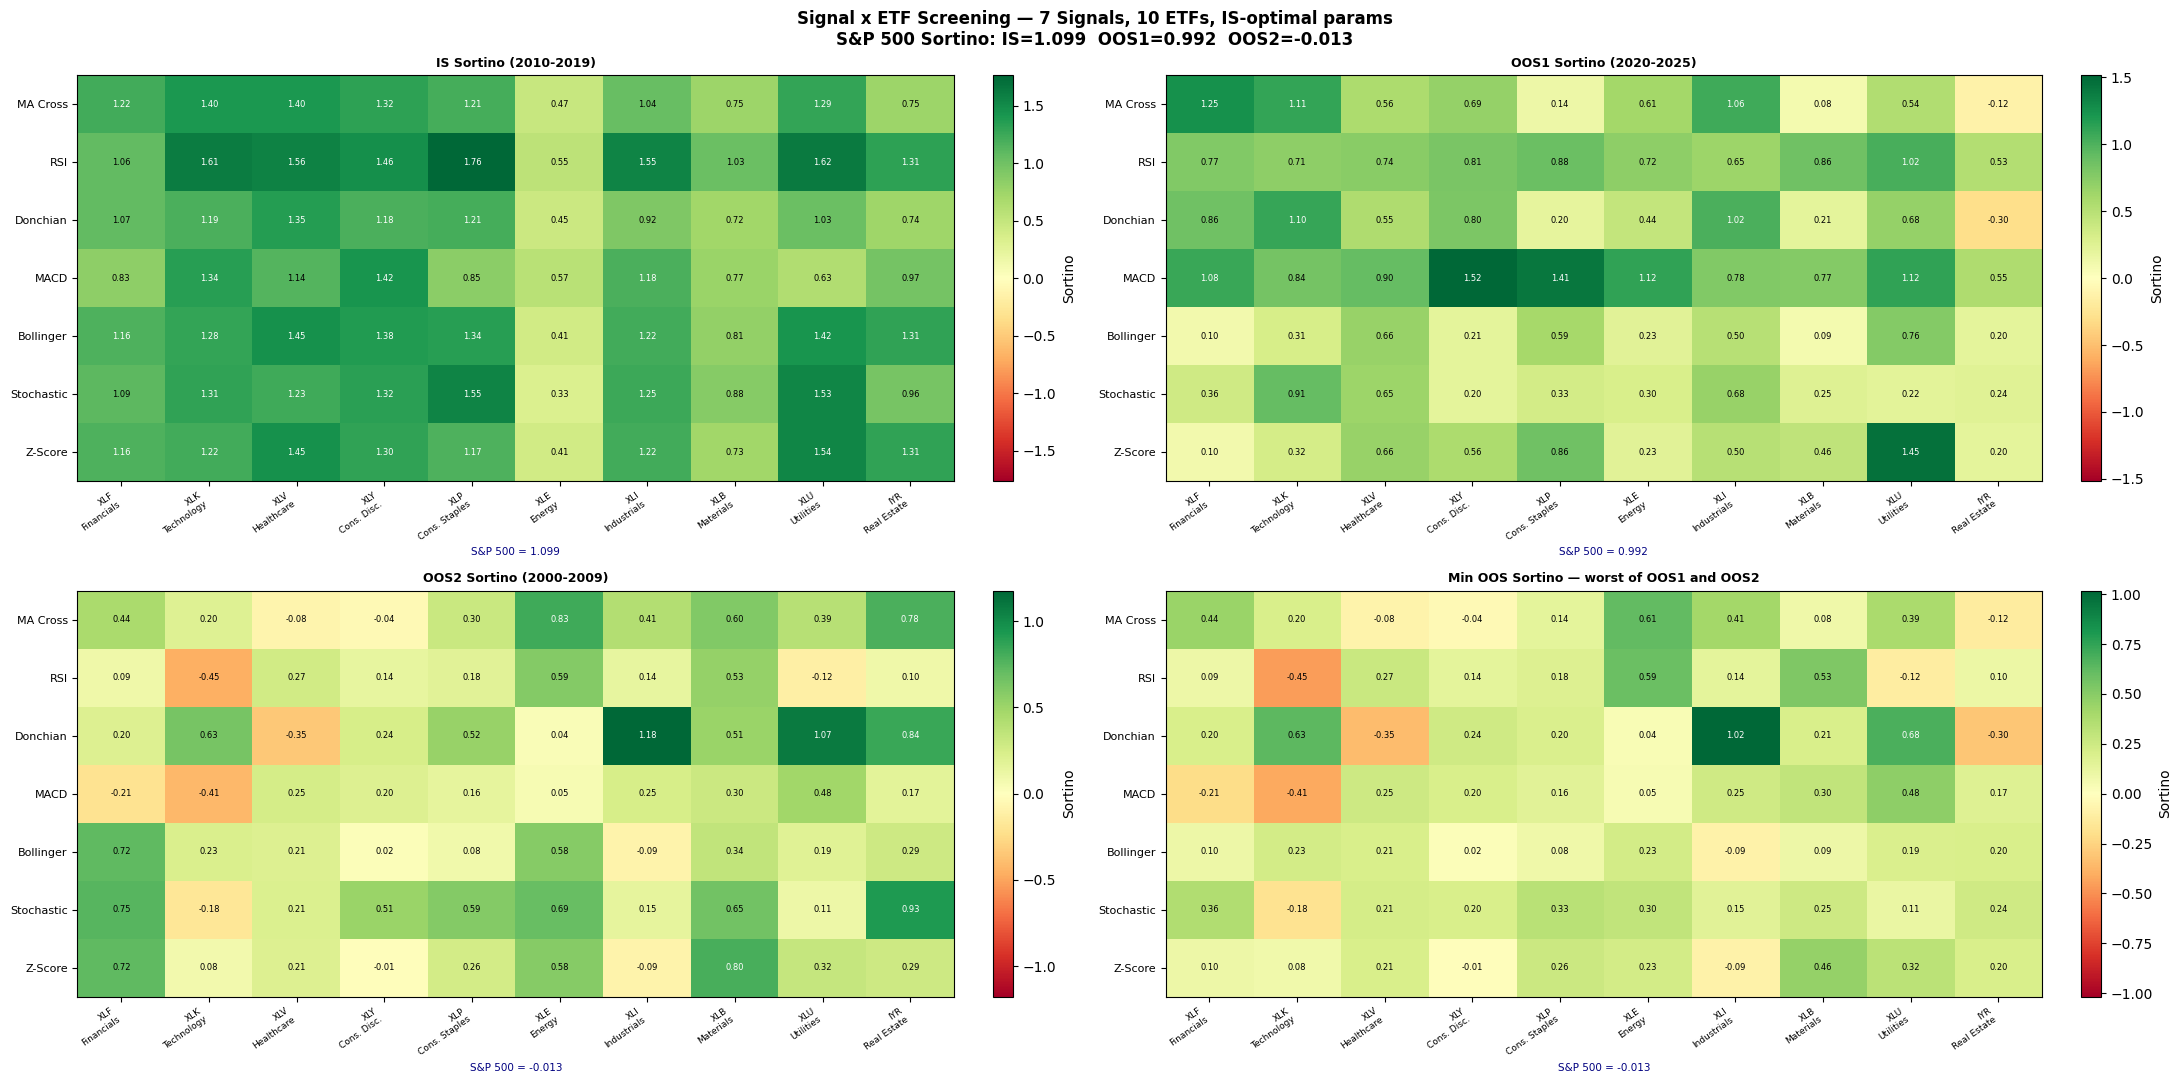

In [21]:
n_sig = len(sig_names)
n_etf = len(TICKERS)

def build_mat(col):
    mat = np.full((n_sig, n_etf), np.nan)
    for r, sn in enumerate(sig_names):
        for c, tk in enumerate(TICKERS):
            row = df[(df['Signal'] == sn) & (df['ETF'] == tk)]
            if len(row):
                mat[r, c] = row[col].values[0]
    return mat

mat_is   = build_mat('IS Sort')
mat_oos1 = build_mat('OOS1 Sort')
mat_oos2 = build_mat('OOS2 Sort')
mat_min  = np.fmin(mat_oos1, mat_oos2)

etf_lbls = [f'{tk}\n{SECTOR_ETFS[tk]}' for tk in TICKERS]

def heatmap(ax, mat, title, spx_ref):
    vabs = max(abs(np.nanmin(mat)), abs(np.nanmax(mat)), 0.01)
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=-vabs, vmax=vabs)
    ax.set_xticks(range(n_etf)); ax.set_xticklabels(etf_lbls, fontsize=6.5, rotation=35, ha='right')
    ax.set_yticks(range(n_sig)); ax.set_yticklabels(sig_names, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    for r in range(n_sig):
        for c in range(n_etf):
            v = mat[r, c]
            if v == v:
                color = 'white' if abs(v) > vabs * 0.65 else 'black'
                ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=6, color=color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Sortino')
    ax.set_xlabel(f'S&P 500 = {spx_ref:.3f}', fontsize=7.5, color='navy')

fig, axes = plt.subplots(2, 2, figsize=(22, 11))
fig.suptitle(
    'Signal x ETF Screening — 7 Signals, 10 ETFs, IS-optimal params\n'
    f'S&P 500 Sortino: IS={SPX_IS:.3f}  OOS1={SPX_OOS1:.3f}  OOS2={SPX_OOS2:.3f}',
    fontsize=12, fontweight='bold')

heatmap(axes[0, 0], mat_is,   'IS Sortino (2010-2019)',                    SPX_IS)
heatmap(axes[0, 1], mat_oos1, 'OOS1 Sortino (2020-2025)',                  SPX_OOS1)
heatmap(axes[1, 0], mat_oos2, 'OOS2 Sortino (2000-2009)',                  SPX_OOS2)
heatmap(axes[1, 1], mat_min,  'Min OOS Sortino — worst of OOS1 and OOS2', min(SPX_OOS1, SPX_OOS2))

plt.tight_layout()
plt.show()

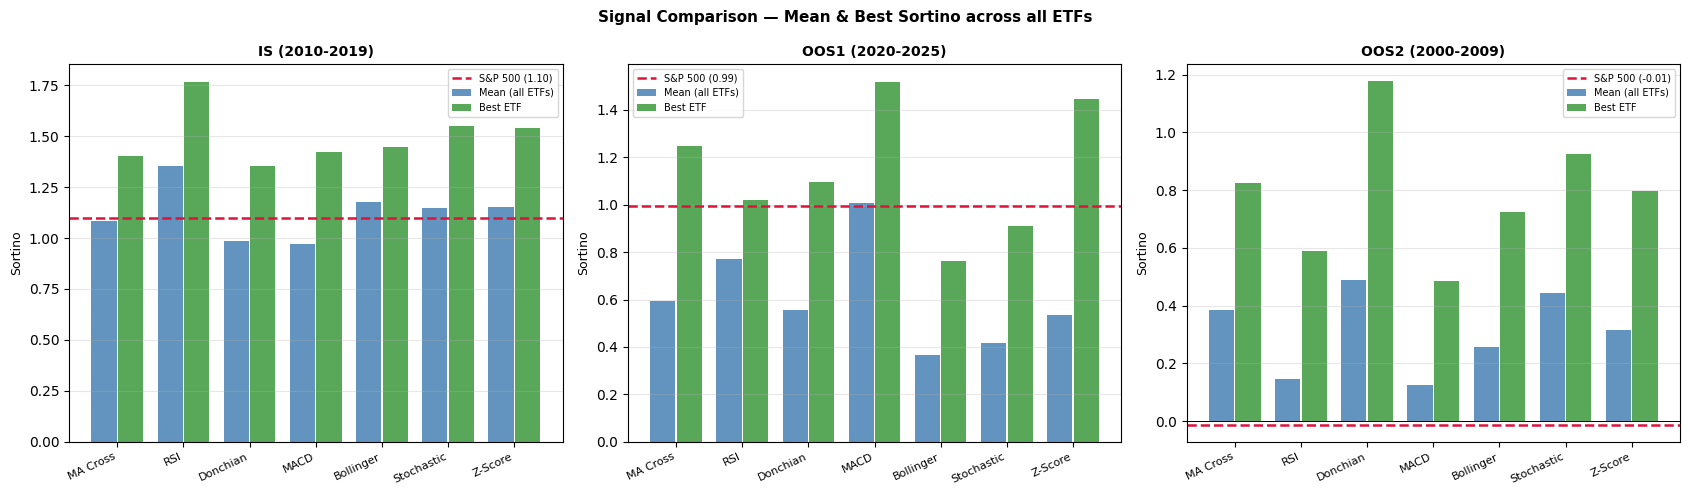

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Signal Comparison — Mean & Best Sortino across all ETFs', fontsize=11, fontweight='bold')

periods = [
    ('IS Sort',   SPX_IS,   'IS (2010-2019)'),
    ('OOS1 Sort', SPX_OOS1, 'OOS1 (2020-2025)'),
    ('OOS2 Sort', SPX_OOS2, 'OOS2 (2000-2009)'),
]
x = np.arange(len(sig_names))

for ax, (col, spx_v, title) in zip(axes, periods):
    means = [df[df['Signal'] == sn][col].mean() for sn in sig_names]
    bests = [df[df['Signal'] == sn][col].max()  for sn in sig_names]
    ax.bar(x - 0.2, means, 0.38, label='Mean (all ETFs)', color='steelblue',   alpha=0.85)
    ax.bar(x + 0.2, bests, 0.38, label='Best ETF',        color='forestgreen', alpha=0.75)
    ax.axhline(spx_v, color='crimson', lw=1.8, linestyle='--', label=f'S&P 500 ({spx_v:.2f})')
    ax.axhline(0,     color='black',   lw=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(sig_names, rotation=25, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Sortino', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

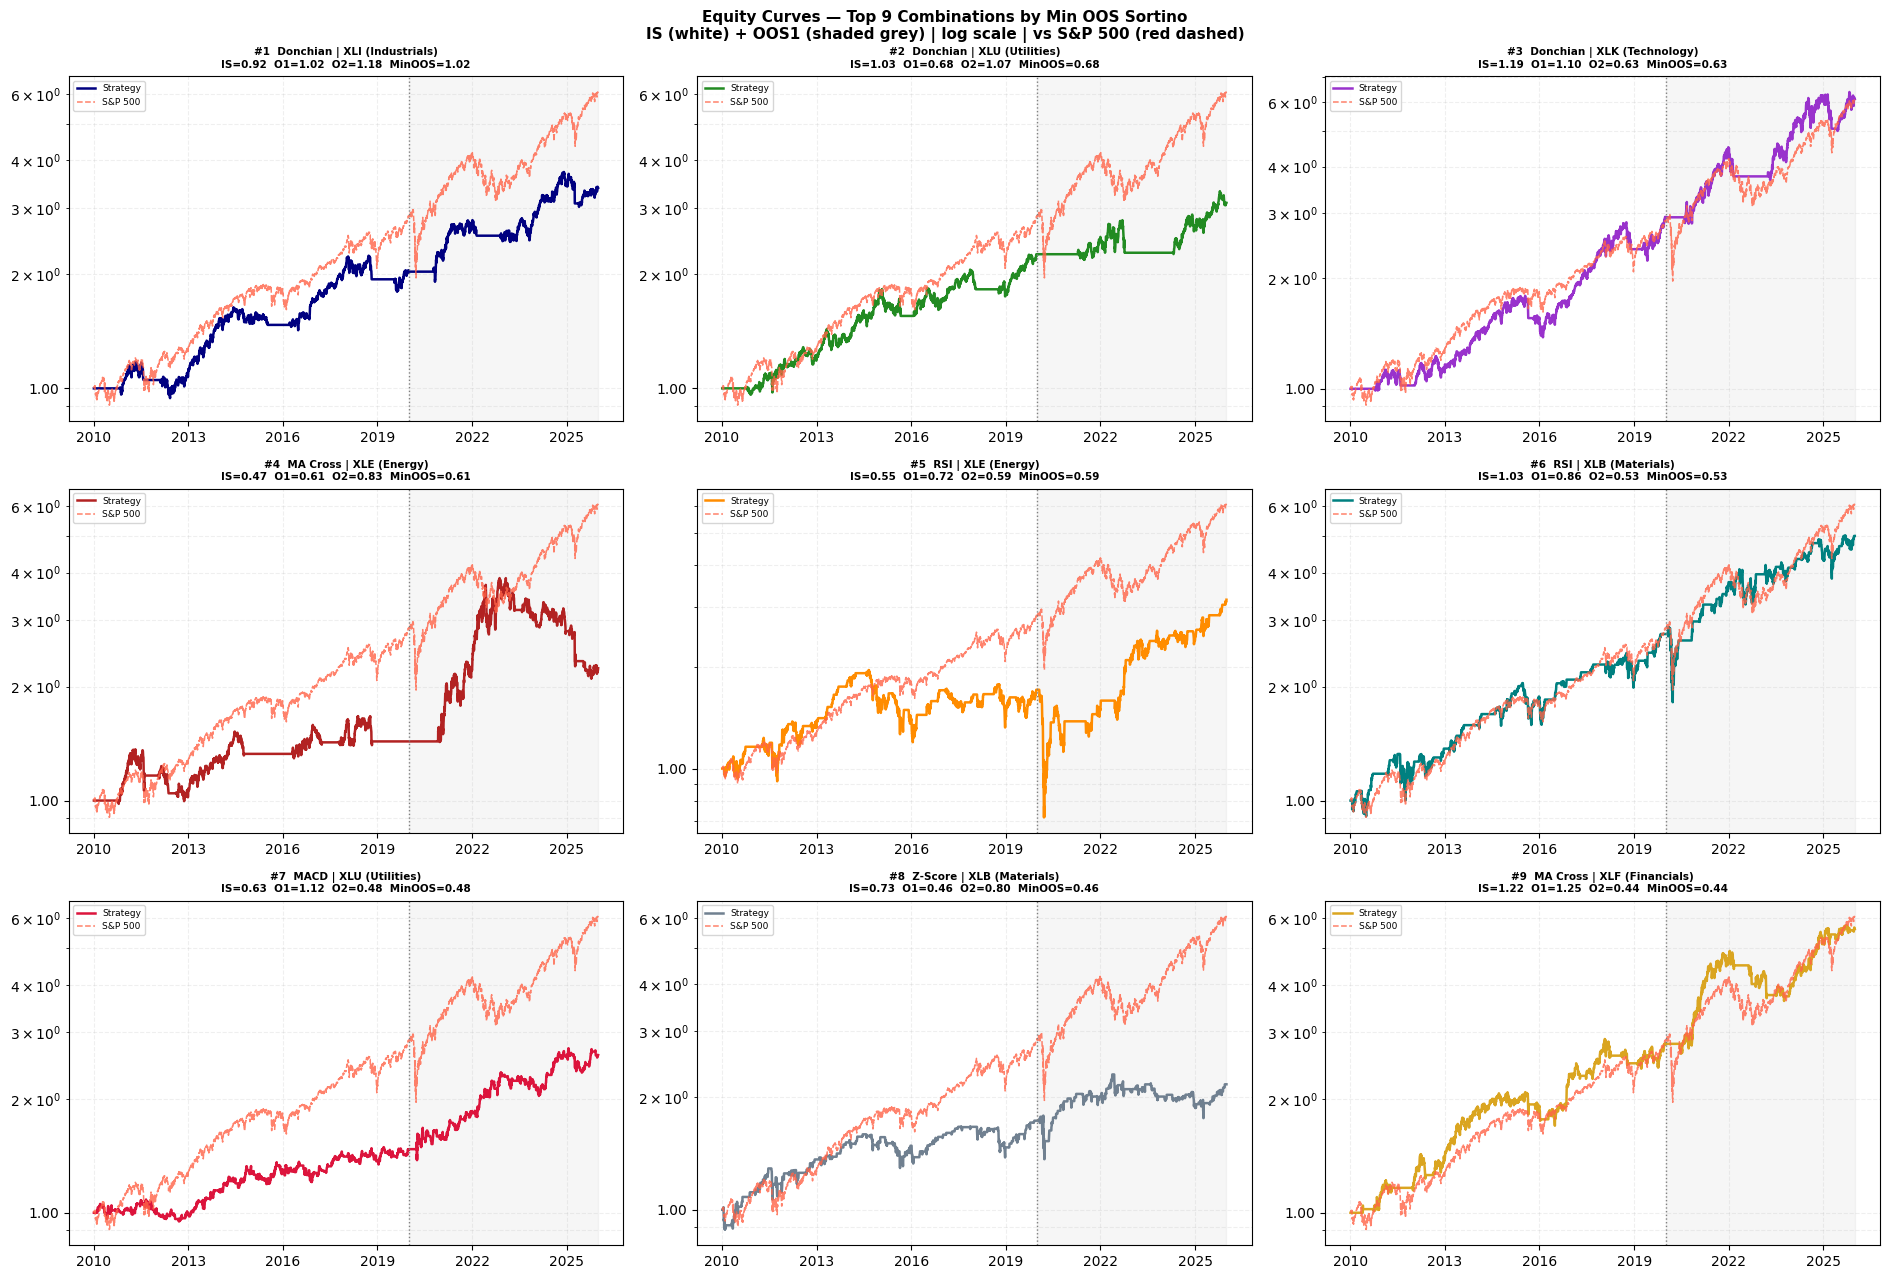

In [23]:
top9 = df.sort_values('Min OOS', ascending=False).head(9).reset_index(drop=True)

def norm_spx(s, e):
    v = cut(df_spx_ext, s, e).iloc[:, 0].to_numpy(dtype=float)
    return v / v[0]

spx_is_n   = norm_spx(IS_START,   IS_END)
spx_o1_n   = norm_spx(OOS1_START, OOS1_END)
spx_stitch = np.concatenate([spx_is_n, spx_o1_n / spx_o1_n[0] * spx_is_n[-1]])
idx_stitch = np.concatenate([df_is.index.to_numpy(), df_oos1.index.to_numpy()])

COLORS = ['navy','forestgreen','darkorchid','firebrick','darkorange',
          'teal','crimson','slategray','goldenrod']

fig, axes = plt.subplots(3, 3, figsize=(19, 13))
fig.suptitle(
    'Equity Curves — Top 9 Combinations by Min OOS Sortino\n'
    'IS (white) + OOS1 (shaded grey) | log scale | vs S&P 500 (red dashed)',
    fontsize=11, fontweight='bold')

for i, (ax, col) in enumerate(zip(axes.flat, COLORS)):
    if i >= len(top9):
        ax.axis('off')
        continue
    r      = top9.iloc[i]
    sn, tk = r['Signal'], r['ETF']
    bp     = opt[sn][tk]['params']
    sig_fn = SIGNAL_GRIDS[sn][0]

    pv_is, _  = backtest(sig_fn, df_is[tk],   bp)
    pv_o1, _  = backtest(sig_fn, df_oos1[tk], bp)
    pv_stitch = np.concatenate([pv_is, pv_o1 / pv_o1[0] * pv_is[-1]])

    line1 = f'#{i+1}  {sn} | {tk} ({r["Sector"]})'
    line2 = (f'IS={r["IS Sort"]:.2f}  O1={r["OOS1 Sort"]:.2f}'
             f'  O2={r["OOS2 Sort"]:.2f}  MinOOS={r["Min OOS"]:.2f}')

    ax.semilogy(idx_stitch, pv_stitch,  color=col,      lw=1.8, label='Strategy')
    ax.semilogy(idx_stitch, spx_stitch, color='tomato', lw=1.1, linestyle='--', alpha=0.8, label='S&P 500')
    ax.axvline(pd.Timestamp(OOS1_START), color='grey', lw=1.0, linestyle=':')
    ax.axvspan(pd.Timestamp(OOS1_START), df_oos1.index[-1], alpha=0.07, color='grey')
    ax.set_title(line1 + '\n' + line2, fontsize=7.5, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.legend(fontsize=6.5)
    ax.grid(True, which='both', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

In [24]:
# Show the optimal IS parameters for the top 20 combinations
top20 = df.sort_values('Min OOS', ascending=False).head(20)
print('OPTIMAL IS PARAMETERS — Top 20 combinations')
print('-' * 70)
for rank, (_, r) in enumerate(top20.iterrows(), 1):
    sn, tk = r['Signal'], r['ETF']
    bp = opt[sn][tk]['params']
    print(f'  {rank:>2}. {sn:<12} {tk:<5}  MinOOS={r["Min OOS"]:>6.3f}  params={bp}')

OPTIMAL IS PARAMETERS — Top 20 combinations
----------------------------------------------------------------------
   1. Donchian     XLI    MinOOS= 1.017  params={'window': 150}
   2. Donchian     XLU    MinOOS= 0.681  params={'window': 200}
   3. Donchian     XLK    MinOOS= 0.634  params={'window': 150}
   4. MA Cross     XLE    MinOOS= 0.614  params={'short_window': 20, 'long_window': 200}
   5. RSI          XLE    MinOOS= 0.589  params={'period': 14, 'oversold': 40, 'overbought': 65}
   6. RSI          XLB    MinOOS= 0.529  params={'period': 14, 'oversold': 40, 'overbought': 65}
   7. MACD         XLU    MinOOS= 0.484  params={'fast_span': 8, 'slow_span': 20, 'signal_span': 9}
   8. Z-Score      XLB    MinOOS= 0.458  params={'window': 10, 'entry_threshold': 1.5}
   9. MA Cross     XLF    MinOOS= 0.441  params={'short_window': 20, 'long_window': 100}
  10. MA Cross     XLI    MinOOS= 0.411  params={'short_window': 50, 'long_window': 100}
  11. MA Cross     XLU    MinOOS= 0.386  para